## Run the following scripts before this notebook.

- `bash rbt/scripts/adh.sh` 
- `bash rbt/scripts/h_protein.sh`
- `python rbt/scripts/cal_protrek_score.py rbt/outputs/adh`
- `python rbt/scripts/cal_protrek_score.py rbt/outputs/h_protein`

In [ ]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np

target_dir = "../outputs/adh"

def read_fasta(file_path, max_seqs=1000000):
    sequences = {}
    current_header = None
    current_sequence = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_header is not None:
                    sequences[current_header] = "".join(current_sequence)
                    current_sequence = []
                current_header = line[1:]
            else:
                current_sequence.append(line)
            if len(sequences) > max_seqs:
                break

        if current_header is not None:
            sequences[current_header] = "".join(current_sequence)

    return sequences

seq_dict = read_fasta(os.path.join(target_dir, "all_seq_token.fasta"))
len(seq_dict)

50000

In [ ]:
seq2ppl = {}
rank_files = Path(target_dir, "rank_files").glob("res_rank*")
for rank_file in rank_files:
    with open(rank_file, "r") as f:
        first_line = f.readline()
        for line in f:
            struct, p_1, seq, p_2 = line.strip().split("\t")
            seq_len = len(seq)
            nll_1 = -float(p_1) / (seq_len + 1)
            nll_2 = -float(p_2) / (seq_len + 2)
            seq2ppl[seq] = np.exp(nll_1 + nll_2)

seq2protrek_score = {}
protrek_score_res_file = os.path.join(target_dir, "all_seq_token.fasta_ProTrekScore.tsv")
with open(protrek_score_res_file, "r") as f:
    for line in f:
        name, score = line.strip().split("\t")
        seq2protrek_score[seq_dict[name]] = float(score)

seq2plddt = {}
plddt_metrics_dict = json.load(open(os.path.join(target_dir, "all_seq_token_esmfold_results.json"), "r"))
for name, seq in seq_dict.items():
    seq2plddt[seq] = plddt_metrics_dict[f"sequence_{name}.pdb_metrics"]["plddt"]

(50000, 50000, 50000)

,PPL interval,PPL center,n,mean ProTrek score,mean pLDDT
0,"[1.0, 2.0)",1.5,36954,15.136035,88.605171
1,"[2.0, 3.0)",2.5,11952,15.590757,89.343879
2,"[3.0, 4.0)",3.5,434,12.488720,86.304302
3,"[4.0, 5.0)",4.5,105,5.514048,80.376747
4,"[5.0, 6.0)",5.5,54,4.804099,72.750239
5,"[6.0, 7.0)",6.5,74,2.444807,66.908795
6,"[7.0, 8.0)",7.5,76,1.242689,57.676007
7,"[8.0, 9.0)",8.5,91,0.478684,57.306390
8,"[9.0, 10.0)",9.5,91,-0.573587,52.881709
9,"[10.0, 11.0)",10.5,45,0.377146,51.765664


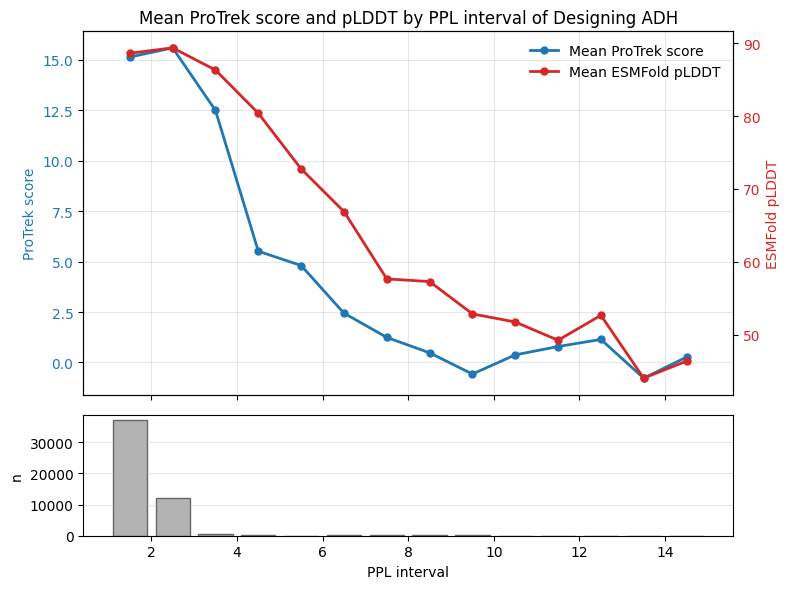

In [ ]:
bin_width = 1.0
min_count = 10

def summarize_scores_by_ppl_interval(ppl_list, protrek_score_list, plddt_list):
    ppl = np.asarray(ppl_list, dtype=float)
    protrek_score = np.asarray(protrek_score_list, dtype=float)
    plddt = np.asarray(plddt_list, dtype=float)
    valid = np.isfinite(ppl) & np.isfinite(protrek_score) & np.isfinite(plddt) & (ppl > 0)
    ppl = ppl[valid]
    protrek_score = protrek_score[valid]
    plddt = plddt[valid]

    bin_start = np.floor(ppl.min() / bin_width) * bin_width
    bin_end = np.ceil(ppl.max() / bin_width) * bin_width
    bins = np.arange(bin_start, bin_end + bin_width, bin_width)
    bin_ids = np.digitize(ppl, bins, right=False) - 1

    rows = []
    for i in range(len(bins) - 1):
        idx = bin_ids == i
        n = int(idx.sum())
        if n < min_count:
            continue
        rows.append({
            "PPL interval": f"[{bins[i]:.1f}, {bins[i + 1]:.1f})",
            "PPL center": (bins[i] + bins[i + 1]) / 2,
            "n": n,
            "mean ProTrek score": float(np.mean(protrek_score[idx])),
            "mean pLDDT": float(np.mean(plddt[idx])),
        })

    try:
        import pandas as pd
        interval_stats = pd.DataFrame(rows)
        display(interval_stats)
    except Exception:
        interval_stats = rows
        for row in rows:
            print(row)

    return rows, interval_stats

def plot_scores_by_ppl_interval(rows):
    centers = np.asarray([row["PPL center"] for row in rows])
    counts = np.asarray([row["n"] for row in rows])
    mean_protrek_score = np.asarray([row["mean ProTrek score"] for row in rows])
    mean_plddt = np.asarray([row["mean pLDDT"] for row in rows])

    fig, (ax_score, ax_count) = plt.subplots(
        2,
        1,
        figsize=(8, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )
    ax_plddt = ax_score.twinx()

    protrek_line = ax_score.plot(
        centers,
        mean_protrek_score,
        "o-",
        color="tab:blue",
        linewidth=2,
        markersize=5,
        label="Mean ProTrek score",
    )
    plddt_line = ax_plddt.plot(
        centers,
        mean_plddt,
        "o-",
        color="tab:red",
        linewidth=2,
        markersize=5,
        label="Mean ESMFold pLDDT",
    )

    ax_score.set_ylabel("ProTrek score", color="tab:blue")
    ax_plddt.set_ylabel("ESMFold pLDDT", color="tab:red")
    ax_score.tick_params(axis="y", labelcolor="tab:blue")
    ax_plddt.tick_params(axis="y", labelcolor="tab:red")
    ax_score.set_title("Mean ProTrek score and pLDDT by PPL interval of Designing ADH")
    ax_score.grid(alpha=0.3)

    lines = protrek_line + plddt_line
    labels = [line.get_label() for line in lines]
    ax_score.legend(lines, labels, frameon=False, loc="upper right")

    ax_count.bar(centers, counts, width=bin_width * 0.8, color="0.7", edgecolor="0.4")
    ax_count.set_xlabel("PPL interval")
    ax_count.set_ylabel("n")
    ax_count.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

seqs = sorted(set(seq2ppl) & set(seq2protrek_score) & set(seq2plddt))
ppl_list = [seq2ppl[seq] for seq in seqs]
protrek_score_list = [seq2protrek_score[seq] for seq in seqs]
plddt_list = [seq2plddt[seq] for seq in seqs]

rows, interval_stats = summarize_scores_by_ppl_interval(ppl_list, protrek_score_list, plddt_list)
plot_scores_by_ppl_interval(rows)